# Zone Model Submission Assessment Notebook

Notebook ini mendokumentasikan **proses pembuatan model zona aktif saat ini** beserta EDA, evaluasi, rekayasa fitur, pemilihan model, pemanfaatan AI/Azure, dan insight strategis.

Fokus notebook:
- hanya memakai **dataset zona aktif expanded** yang sedang dipakai model saat ini
- menampilkan artefak yang relevan untuk penilaian lomba
- tetap memberi opsi untuk **rebuild dataset** dan **retrain model** bila diperlukan


## Kriteria Penilaian yang Ditargetkan

Notebook ini disusun agar mudah dipetakan ke rubric:

1. **Metodologi dan Eksplorasi Data**
2. **Performa Model dan Kualitas Kode**
3. **Pemanfaatan AI dan Layanan Microsoft Azure**
4. **Insight dan Solusi Strategis**

Metrik seleksi utama tetap **macro F1**, karena dataset expanded masih imbalance dan beberapa kelas memiliki support rendah.


## Setup Lokal / Colab

Jika dijalankan di Google Colab:
- upload atau mount seluruh folder project, bukan file notebook saja
- simpan project di `/content/DATAHACTHON` atau di Google Drive
- bila perlu set `COLAB_PROJECT_ROOT`


In [1]:
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
MOUNT_GOOGLE_DRIVE = False
COLAB_PROJECT_ROOT = None
# Contoh:
# MOUNT_GOOGLE_DRIVE = True
# COLAB_PROJECT_ROOT = "/content/drive/MyDrive/DATAHACTHON"

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

if IN_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pandas",
            "numpy",
            "matplotlib",
            "seaborn",
            "scikit-learn",
            "joblib",
            "catboost",
            "lightgbm",
            "xgboost",
            "openai",
            "azure-identity",
            "nbformat",
        ]
    )


def _is_project_root(path: Path) -> bool:
    return (path / "scripts").exists() and (path / "data").exists() and (path / "artifacts").exists()


def resolve_project_root(explicit_root: str | None = None) -> Path:
    if explicit_root:
        candidate = Path(explicit_root).expanduser().resolve()
        if _is_project_root(candidate):
            return candidate
        raise FileNotFoundError(
            f"COLAB_PROJECT_ROOT tidak valid: {candidate}. "
            "Folder harus mengandung `scripts/`, `data/`, dan `artifacts/`."
        )

    cwd = Path.cwd().resolve()
    direct_candidates = [
        cwd,
        *cwd.parents,
        Path("/content/DATAHACTHON"),
        Path("/content/drive/MyDrive/DATAHACTHON"),
        Path("/content/drive/MyDrive/Colab Notebooks/DATAHACTHON"),
    ]
    seen = set()
    for candidate in direct_candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists() and _is_project_root(candidate):
            return candidate
    raise FileNotFoundError("Project root tidak ditemukan. Set COLAB_PROJECT_ROOT bila perlu.")


PROJECT_ROOT = resolve_project_root(COLAB_PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("IN_COLAB =", IN_COLAB)
print("PROJECT_ROOT =", PROJECT_ROOT)


IN_COLAB = False
PROJECT_ROOT = /home/stardust/Documents/Kuliah/DATAHACTHON


## Konfigurasi Eksekusi

- `REBUILD_DATASET`: membangun ulang dataset expanded dari pipeline integrasi data
- `RETRAIN_MODEL`: melatih ulang model expanded aktif
- `REFRESH_ASSESSMENT_ARTIFACTS`: menyegarkan EDA summary, scorecard, per-class metrics, dan feature importance

Default notebook memakai artifact aktif agar lebih cepat dibuka, tetapi tetap merepresentasikan pipeline model saat ini.


In [2]:
REBUILD_DATASET = False
RETRAIN_MODEL = False
REFRESH_ASSESSMENT_ARTIFACTS = True
RANDOM_STATE = 42


In [3]:
import json
from pprint import pprint

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

from app.core.config import Settings
from scripts.assess_zone_submission import main as assess_submission
from scripts.common import PROJECT_ROOT as CODE_PROJECT_ROOT
from scripts.prepare_zone_dataset_expanded import main as prepare_zone_dataset_expanded
from scripts.train_zone_model_expanded import main as train_zone_model_expanded


## 1. Rebuild Pipeline Opsional

Cell ini membuat notebook tetap jujur terhadap proses model saat ini. Jika flag diaktifkan:
- dataset expanded akan dibangun ulang
- model expanded akan dilatih ulang
- artefak penilaian akan disegarkan


In [4]:
if REBUILD_DATASET:
    preparation_summary = prepare_zone_dataset_expanded()
    print("Dataset expanded rebuilt.")
    pprint(preparation_summary if preparation_summary is not None else {})

if RETRAIN_MODEL:
    training_summary = train_zone_model_expanded()
    print("Expanded model retrained.")
    pprint(training_summary if training_summary is not None else {})

if REFRESH_ASSESSMENT_ARTIFACTS:
    assess_submission()
    print("Assessment artifacts refreshed.")


{
  "eda_summary": "artifacts/eda_zone_expanded.md",
  "per_class_metrics": "artifacts/per_class_metrics_expanded.csv",
  "feature_importance": "artifacts/feature_importance_best_model_expanded.csv",
  "scorecard": "artifacts/submission_scorecard.md"
}
Assessment artifacts refreshed.


## 2. Load Dataset dan Artifact Aktif

Dataset dan artefak yang dipakai notebook ini:
- `data/processed/zone_dataset_expanded_id.csv`
- `data/processed/zone_dataset_expanded_id_metadata.json`
- `artifacts/best_model_metrics_expanded.json`
- `artifacts/model_comparison_expanded.csv`
- `artifacts/per_class_metrics_expanded.csv`
- `artifacts/feature_importance_best_model_expanded.csv`
- `artifacts/submission_scorecard.md`


In [5]:
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "zone_dataset_expanded_id.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "zone_dataset_expanded_id_metadata.json"
METRICS_PATH = PROJECT_ROOT / "artifacts" / "best_model_metrics_expanded.json"
COMPARISON_PATH = PROJECT_ROOT / "artifacts" / "model_comparison_expanded.csv"
PER_CLASS_PATH = PROJECT_ROOT / "artifacts" / "per_class_metrics_expanded.csv"
IMPORTANCE_PATH = PROJECT_ROOT / "artifacts" / "feature_importance_best_model_expanded.csv"
SCORECARD_PATH = PROJECT_ROOT / "artifacts" / "submission_scorecard.md"

zone_df = pd.read_csv(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
metrics_payload = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
comparison_df = pd.read_csv(COMPARISON_PATH)
per_class_df = pd.read_csv(PER_CLASS_PATH)
importance_df = pd.read_csv(IMPORTANCE_PATH)

selected_scenario = metrics_payload["selected_zone_scenario"]
selected_metrics = metrics_payload["selected_zone_test_metrics"]
selected_feature_columns = metrics_payload[selected_scenario]["feature_columns"]

print("Dataset shape:", zone_df.shape)
print("Selected scenario:", selected_scenario)
print("Selected model:", metrics_payload["selected_zone_model_name"])
print("Feature count:", len(selected_feature_columns))


Dataset shape: (77, 66)
Selected scenario: zone_mean_plus_variability
Selected model: extra_trees
Feature count: 57


## 3. Snapshot Dataset Aktif

Section ini menjawab bagian audit dasar:
- target aktif
- jumlah kelas
- distribusi sumber data
- ukuran dataset
- struktur zona dan group split


In [6]:
snapshot_df = pd.DataFrame(
    [
        {"item": "dataset_path", "value": str(DATASET_PATH.relative_to(PROJECT_ROOT))},
        {"item": "target_column", "value": metrics_payload["target_column"]},
        {"item": "jumlah_zona", "value": zone_df.shape[0]},
        {"item": "jumlah_kelas", "value": zone_df[metrics_payload["target_column"]].nunique()},
        {"item": "jumlah_konteks", "value": zone_df["base_context_id"].nunique()},
        {"item": "selected_scenario", "value": selected_scenario},
        {"item": "selected_model", "value": metrics_payload["selected_zone_model_name"]},
        {"item": "group_split", "value": metrics_payload["split_strategy"]["group_column"]},
    ]
)
display(snapshot_df)
display(zone_df.head())


,item,value
0,dataset_path,data/processed/zone_dataset_expanded_id.csv
1,target_column,zone_target
2,jumlah_zona,77
3,jumlah_kelas,13
4,jumlah_konteks,53
5,selected_scenario,zone_mean_plus_variability
6,selected_model,extra_trees
7,group_split,base_context_id


,zone_id,base_context_id,source_dataset,source_region,integration_strategy,sample_count,context_sample_count,context_cluster_count,sample_count_risk_flag,label_nunique,zone_label_dominance_ratio,ph_mean,ph_std,ph_min,ph_max,ph_median,ph_count,ph_range,ph_cv,ph_missing_ratio,nitrogen_mean,nitrogen_std,nitrogen_min,nitrogen_max,nitrogen_median,nitrogen_count,nitrogen_range,nitrogen_cv,nitrogen_missing_ratio,phosphorus_mean,phosphorus_std,phosphorus_min,phosphorus_max,phosphorus_median,phosphorus_count,phosphorus_range,phosphorus_cv,phosphorus_missing_ratio,potassium_mean,potassium_std,potassium_min,potassium_max,potassium_median,potassium_count,potassium_range,potassium_cv,potassium_missing_ratio,temperature_mean_mean,temperature_mean_std,temperature_mean_min,temperature_mean_max,temperature_mean_median,temperature_mean_count,temperature_mean_range,temperature_mean_cv,temperature_mean_missing_ratio,rainfall_mean_mean,rainfall_mean_std,rainfall_mean_min,rainfall_mean_max,rainfall_mean_median,rainfall_mean_count,rainfall_mean_range,rainfall_mean_cv,rainfall_mean_missing_ratio,zone_target
0,active::zone_01_02,active::1,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,20,236,9,ok,3,0.700000,6.762667,0.306931,6.40,7.37,6.700,15,0.97,0.045386,0.0,0.191767,0.035838,0.1417,0.2518,0.19470,15,0.1101,0.186882,0.0,8.579000,9.290769,2.000,34.000,6.000,15,32.000,1.082966,0.0,385.592800,99.199484,208.600,537.000,387.000,15,328.400,0.257265,0.0,13.937083,0.0,13.937083,13.937083,13.937083,15,0.0,0.0,0.0,3.288333,0.0,3.288333,3.288333,3.288333,15,0.0,0.0,0.0,Gandum
1,active::zone_01_03,active::1,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,58,236,9,ok,3,0.603448,5.715769,0.204262,5.28,6.35,5.705,52,1.07,0.035737,0.0,0.246537,0.025635,0.1679,0.2992,0.25180,52,0.1313,0.103980,0.0,13.815135,15.138170,4.267,85.046,8.804,52,80.779,1.095767,0.0,223.305635,93.837547,55.537,507.187,205.185,52,451.650,0.420220,0.0,13.937083,0.0,13.937083,13.937083,13.937083,52,0.0,0.0,0.0,3.288333,0.0,3.288333,3.288333,3.288333,52,0.0,0.0,0.0,Jelai
2,active::zone_01_08,active::1,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,21,236,9,ok,2,0.952381,5.854286,0.261698,5.50,6.40,5.800,21,0.90,0.044702,0.0,0.343938,0.041740,0.2860,0.4366,0.34110,21,0.1506,0.121360,0.0,10.156190,8.193431,3.000,34.000,7.000,21,31.000,0.806743,0.0,259.322333,111.921925,60.769,445.000,258.000,21,384.231,0.431594,0.0,13.937083,0.0,13.937083,13.937083,13.937083,21,0.0,0.0,0.0,3.288333,0.0,3.288333,3.288333,3.288333,21,0.0,0.0,0.0,Jelai
3,active::zone_02_05,active::2,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,59,286,11,ok,6,0.711864,5.248772,0.278459,4.30,5.91,5.200,57,1.61,0.053052,0.0,0.168420,0.026202,0.1094,0.2289,0.16230,57,0.1195,0.155578,0.0,4.776140,2.527142,1.000,12.000,4.000,57,11.000,0.529118,0.0,296.384386,98.488825,85.000,501.000,288.000,57,416.000,0.332301,0.0,17.892500,0.0,17.892500,17.892500,17.892500,57,0.0,0.0,0.0,4.475833,0.0,4.475833,4.475833,4.475833,57,0.0,0.0,0.0,Teff
4,active::zone_06_11,active::6,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,24,457,18,ok,5,0.708333,6.600455,0.475840,5.80,7.30,6.650,22,1.50,0.072092,0.0,0.155805,0.034447,0.0742,0.2118,0.15185,22,0.1376,0.221089,0.0,68.168182,44.467038,4.000,138.000,77.000,22,134.000,0.652314,0.0,664.590909,137.121656,407.000,933.000,632.500,22,526.000,0.206325,0.0,16.695000,0.0,16.695000,16.695000,16.695000,22,0.0,0.0,0.0,5.371667,0.0,5.371667,5.371667,5.371667,22,0.0,0.0,0.0,Teff


## 4. EDA: Distribusi Kelas dan Sumber Data

Ini bagian utama untuk penilaian **Metodologi dan Eksplorasi Data**.


,label,zone_count
0,Jagung,17
1,Teff,12
2,Padi,6
3,Pisang,6
4,Kelapa,5
5,Mangga,5
6,Gandum,4
7,Jelai,4
8,Jeruk,4
9,Semangka,4


,source_dataset,zone_count
0,crop_recommendation_kaggle_mirror,44
1,mendeley_8v757rr4st_crop_recommendation_soil_w...,33


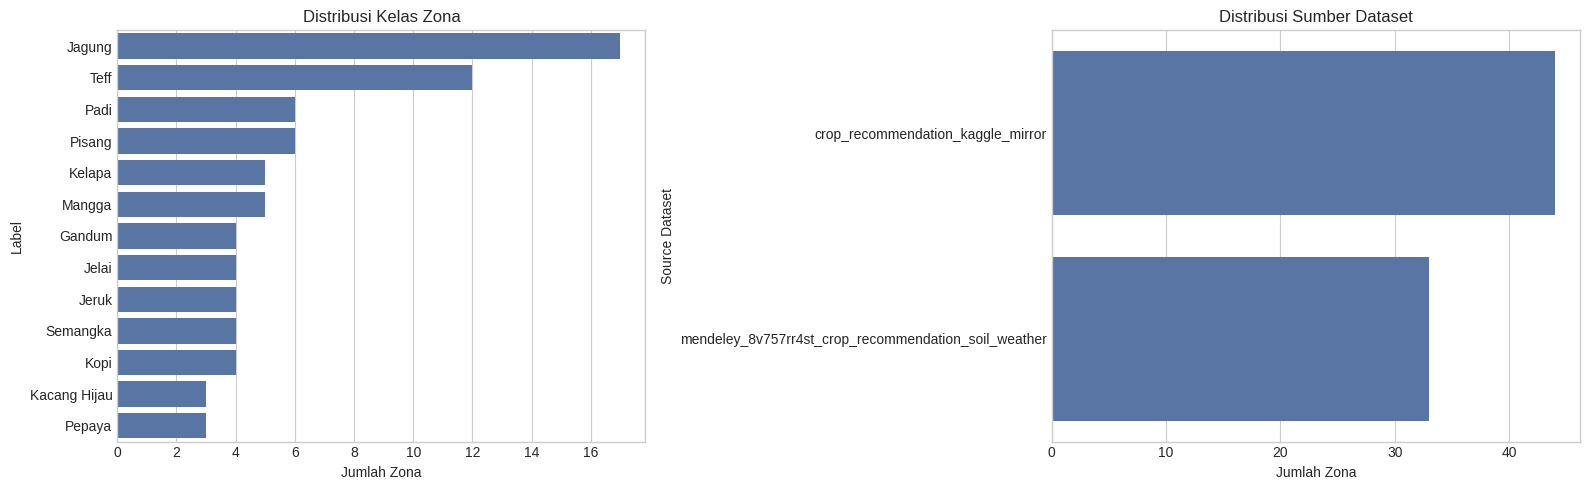

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

target_counts = zone_df[metrics_payload["target_column"]].value_counts()
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0])
axes[0].set_title("Distribusi Kelas Zona")
axes[0].set_xlabel("Jumlah Zona")
axes[0].set_ylabel("Label")

source_counts = zone_df["source_dataset"].value_counts()
sns.barplot(x=source_counts.values, y=source_counts.index, ax=axes[1])
axes[1].set_title("Distribusi Sumber Dataset")
axes[1].set_xlabel("Jumlah Zona")
axes[1].set_ylabel("Source Dataset")

plt.tight_layout()
display(target_counts.rename_axis("label").reset_index(name="zone_count"))
display(source_counts.rename_axis("source_dataset").reset_index(name="zone_count"))


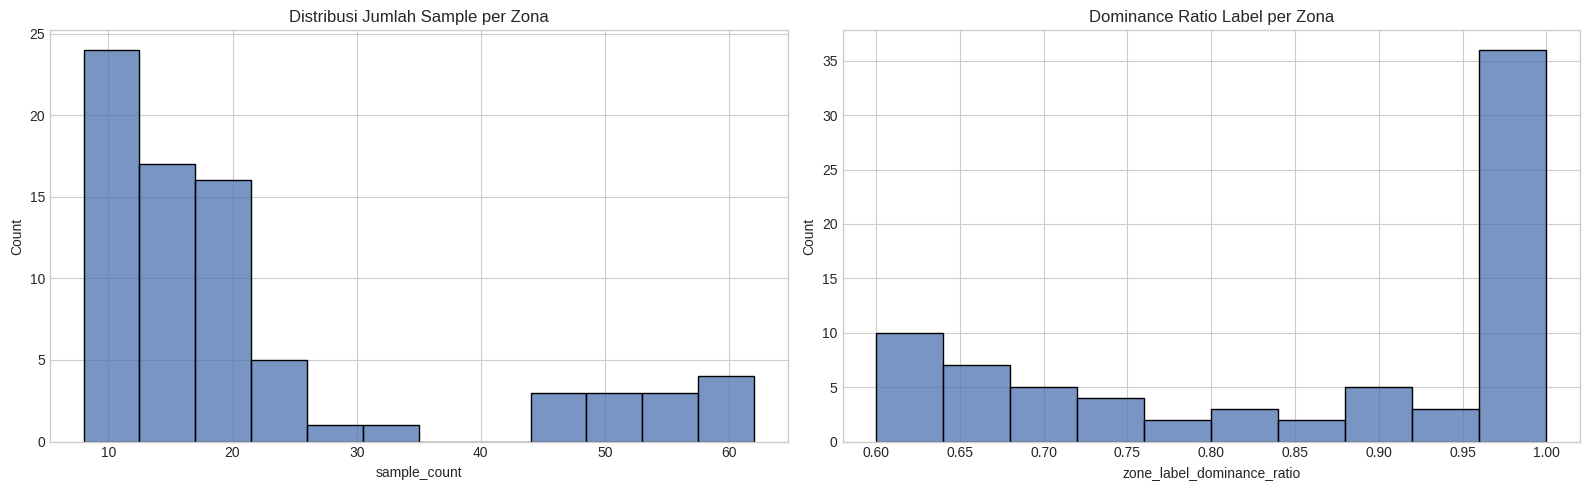

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(zone_df["sample_count"], bins=12, ax=axes[0])
axes[0].set_title("Distribusi Jumlah Sample per Zona")
axes[0].set_xlabel("sample_count")

if "zone_label_dominance_ratio" in zone_df.columns:
    sns.histplot(zone_df["zone_label_dominance_ratio"], bins=10, ax=axes[1])
    axes[1].set_title("Dominance Ratio Label per Zona")
    axes[1].set_xlabel("zone_label_dominance_ratio")
else:
    axes[1].axis("off")

plt.tight_layout()


## 5. EDA: Kualitas Fitur dan Missing Values

Karena model aktif memakai feature schema fixed, kualitas fitur dan kelengkapan kolom perlu ditampilkan secara eksplisit.


In [9]:
missing_df = (
    zone_df[selected_feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_ratio")
    .reset_index()
    .rename(columns={"index": "feature"})
)

quality_summary = pd.DataFrame(
    [
        {"metric": "feature_count", "value": len(selected_feature_columns)},
        {"metric": "mean_missing_ratio", "value": float(zone_df[selected_feature_columns].isna().mean().mean())},
        {"metric": "max_missing_ratio", "value": float(zone_df[selected_feature_columns].isna().mean().max())},
        {"metric": "group_column_unique", "value": int(zone_df["base_context_id"].nunique())},
    ]
)
display(quality_summary)
display(missing_df.head(15))


,metric,value
0,feature_count,57.0
1,mean_missing_ratio,0.0
2,max_missing_ratio,0.0
3,group_column_unique,53.0


,feature,missing_ratio
0,sample_count,0.0
1,context_sample_count,0.0
2,context_cluster_count,0.0
3,ph_mean,0.0
4,ph_std,0.0
5,ph_min,0.0
6,ph_max,0.0
7,ph_median,0.0
8,ph_count,0.0
9,ph_range,0.0


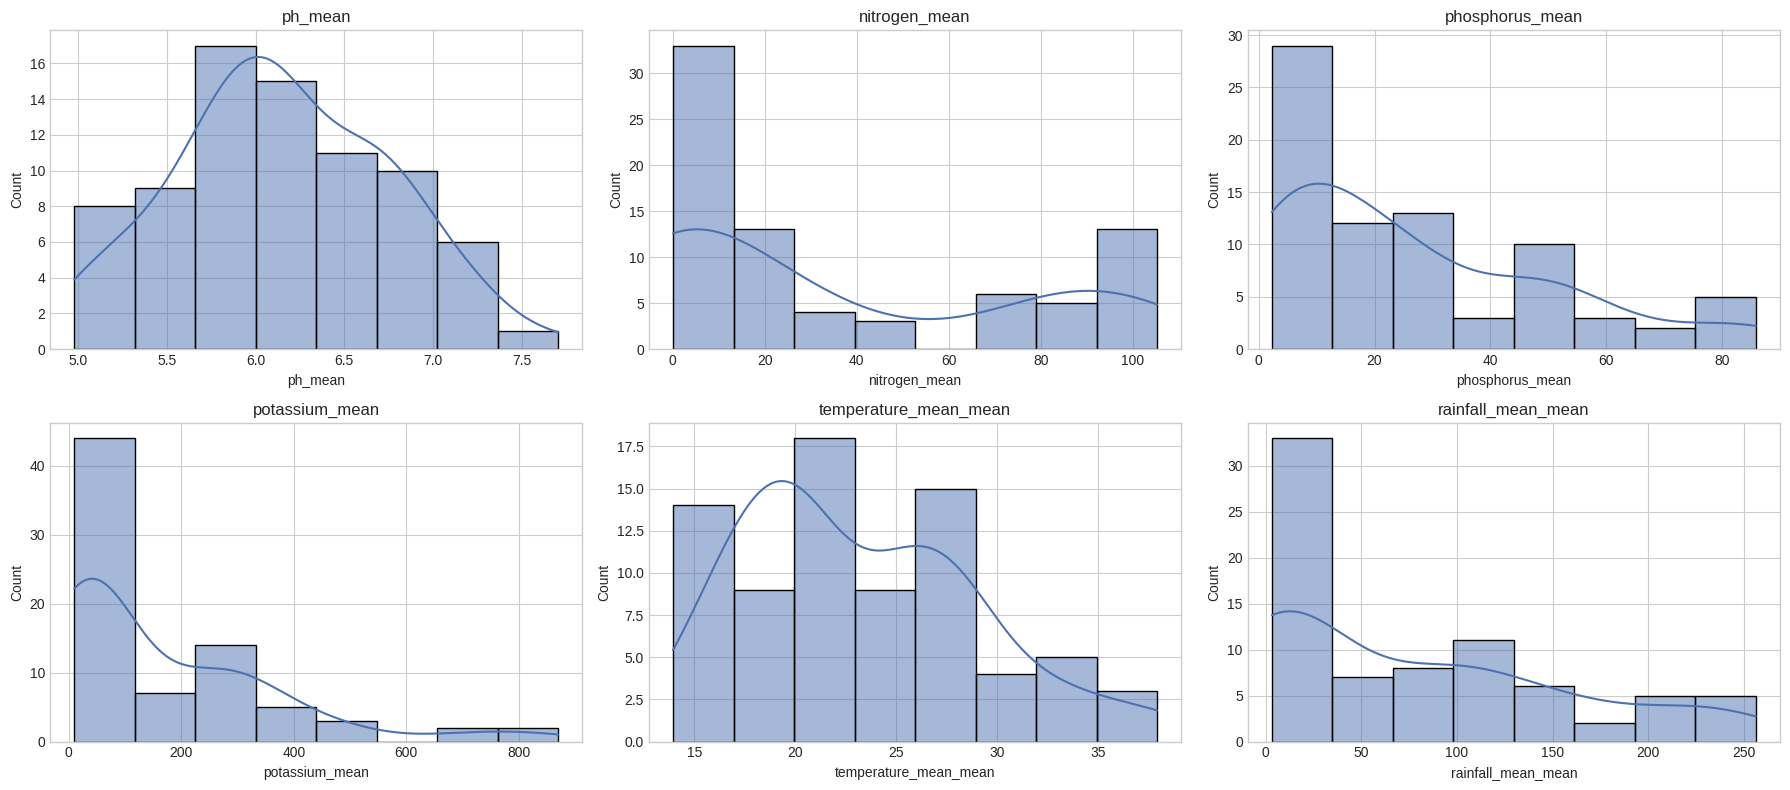

In [10]:
core_mean_features = [
    column
    for column in [
        "ph_mean",
        "nitrogen_mean",
        "phosphorus_mean",
        "potassium_mean",
        "temperature_mean_mean",
        "rainfall_mean_mean",
    ]
    if column in zone_df.columns
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for ax, column in zip(axes, core_mean_features):
    sns.histplot(zone_df[column], kde=True, ax=ax)
    ax.set_title(column)
for ax in axes[len(core_mean_features):]:
    ax.axis("off")
plt.tight_layout()


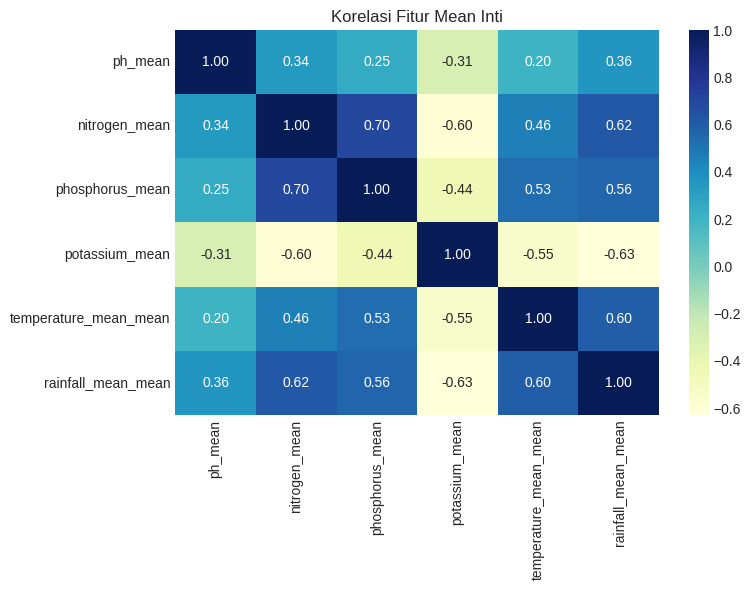

In [11]:
corr_columns = [column for column in core_mean_features if zone_df[column].nunique() > 1]
corr_matrix = zone_df[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Korelasi Fitur Mean Inti")
plt.tight_layout()


## 6. Rekayasa Fitur dan Strategi Integrasi

Ringkasan feature engineering model saat ini:
- unit analisis: **zona**
- skenario terpilih: **mean plus variability**
- fitur yang dipakai tidak hanya mean, tetapi juga `std`, `min`, `max`, `median`, `count`, `range`, `cv`, `missing_ratio`
- split evaluasi memakai `base_context_id` agar kebocoran antarkonteks ditekan


In [12]:
scenario_summary = pd.DataFrame(
    [
        {
            "scenario": "zone_mean_only",
            "feature_count": len(metrics_payload["zone_mean_only"]["feature_columns"]),
            "best_model": metrics_payload["zone_mean_only"]["best_model_name"],
            "cv_macro_f1": metrics_payload["zone_mean_only"]["tuned_cv_f1_macro"],
            "test_macro_f1": metrics_payload["zone_mean_only"]["test_metrics"]["f1_macro"],
        },
        {
            "scenario": "zone_mean_plus_variability",
            "feature_count": len(metrics_payload["zone_mean_plus_variability"]["feature_columns"]),
            "best_model": metrics_payload["zone_mean_plus_variability"]["best_model_name"],
            "cv_macro_f1": metrics_payload["zone_mean_plus_variability"]["tuned_cv_f1_macro"],
            "test_macro_f1": metrics_payload["zone_mean_plus_variability"]["test_metrics"]["f1_macro"],
        },
    ]
)
display(scenario_summary)


,scenario,feature_count,best_model,cv_macro_f1,test_macro_f1
0,zone_mean_only,9,extra_trees,0.732338,0.884615
1,zone_mean_plus_variability,57,extra_trees,0.805739,0.830769


## 7. Perbandingan Model

Section ini menjawab bagian **Performa Model dan Kualitas Kode**.

Kandidat yang dibandingkan pada pipeline expanded:
- Logistic Regression
- Random Forest
- Extra Trees
- LightGBM
- CatBoost
- XGBoost


In [13]:
display(
    comparison_df.sort_values(
        ["scenario_name", "cv_f1_macro_mean", "test_f1_macro"],
        ascending=[True, False, False],
    ).reset_index(drop=True)
)


,scenario_name,model_name,fit_status,selection_strategy,cv_splits,cv_accuracy_mean,cv_precision_macro_mean,cv_recall_macro_mean,cv_f1_macro_mean,cv_f1_weighted_mean,cv_accuracy_std,cv_f1_macro_std,selected_for_tuning,is_scenario_winner,is_final_selected,tuned_cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_params_json,error_message
0,zone_mean_only,extra_trees,success,stratified_group_kfold,2,0.716524,0.744017,0.780983,0.732338,0.695187,0.024217,0.023791,True,True,False,0.732338,0.916667,0.884615,0.884615,0.884615,0.916667,"{""model__n_estimators"": 360, ""model__min_sampl...",NaN
1,zone_mean_only,logistic_regression,success,stratified_group_kfold,2,0.623932,0.747436,0.733974,0.724176,0.632112,0.068376,0.001099,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,zone_mean_only,catboost,success,stratified_group_kfold,2,0.510684,0.610989,0.673077,0.607942,0.469133,0.066239,0.031252,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,zone_mean_only,lightgbm,success,stratified_group_kfold,2,0.605413,0.624237,0.632479,0.602875,0.596357,0.086895,0.053535,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,zone_mean_only,random_forest,success,stratified_group_kfold,2,0.564103,0.499359,0.569444,0.492054,0.509862,0.102564,0.081664,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,zone_mean_only,xgboost,success,stratified_group_kfold,2,0.525641,0.383089,0.477564,0.399263,0.456647,0.141026,0.166803,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,zone_mean_plus_variability,extra_trees,success,stratified_group_kfold,2,0.772792,0.816667,0.829060,0.805739,0.758866,0.042023,0.066056,True,True,True,0.805739,0.875000,0.820513,0.846154,0.830769,0.841667,"{""model__n_estimators"": 360, ""model__min_sampl...",NaN
7,zone_mean_plus_variability,logistic_regression,success,stratified_group_kfold,2,0.735755,0.775000,0.785256,0.768602,0.731607,0.004986,0.016466,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,zone_mean_plus_variability,catboost,success,stratified_group_kfold,2,0.622507,0.729167,0.733974,0.687821,0.617901,0.007123,0.030128,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,zone_mean_plus_variability,random_forest,success,stratified_group_kfold,2,0.640313,0.657234,0.679487,0.635780,0.599008,0.063390,0.084132,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
best_row = comparison_df.loc[comparison_df["is_final_selected"] == True].copy()
display(best_row)

selected_metrics_df = pd.DataFrame(
    [
        {"metric": "accuracy", "value": selected_metrics["accuracy"]},
        {"metric": "precision_macro", "value": selected_metrics["precision_macro"]},
        {"metric": "recall_macro", "value": selected_metrics["recall_macro"]},
        {"metric": "f1_macro", "value": selected_metrics["f1_macro"]},
        {"metric": "f1_weighted", "value": selected_metrics["f1_weighted"]},
        {"metric": "cv_f1_macro", "value": metrics_payload["selected_zone_cv_metric_value"]},
    ]
)
display(selected_metrics_df)


,scenario_name,model_name,fit_status,selection_strategy,cv_splits,cv_accuracy_mean,cv_precision_macro_mean,cv_recall_macro_mean,cv_f1_macro_mean,cv_f1_weighted_mean,cv_accuracy_std,cv_f1_macro_std,selected_for_tuning,is_scenario_winner,is_final_selected,tuned_cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_params_json,error_message
6,zone_mean_plus_variability,extra_trees,success,stratified_group_kfold,2,0.772792,0.816667,0.82906,0.805739,0.758866,0.042023,0.066056,True,True,True,0.805739,0.875,0.820513,0.846154,0.830769,0.841667,"{""model__n_estimators"": 360, ""model__min_sampl...",NaN


,metric,value
0,accuracy,0.875000
1,precision_macro,0.820513
2,recall_macro,0.846154
3,f1_macro,0.830769
4,f1_weighted,0.841667
5,cv_f1_macro,0.805739


## 8. Evaluasi Final Model Terpilih

Macro F1 tetap dijadikan acuan utama karena distribusi kelas tidak seimbang dan beberapa kelas hanya memiliki support rendah.


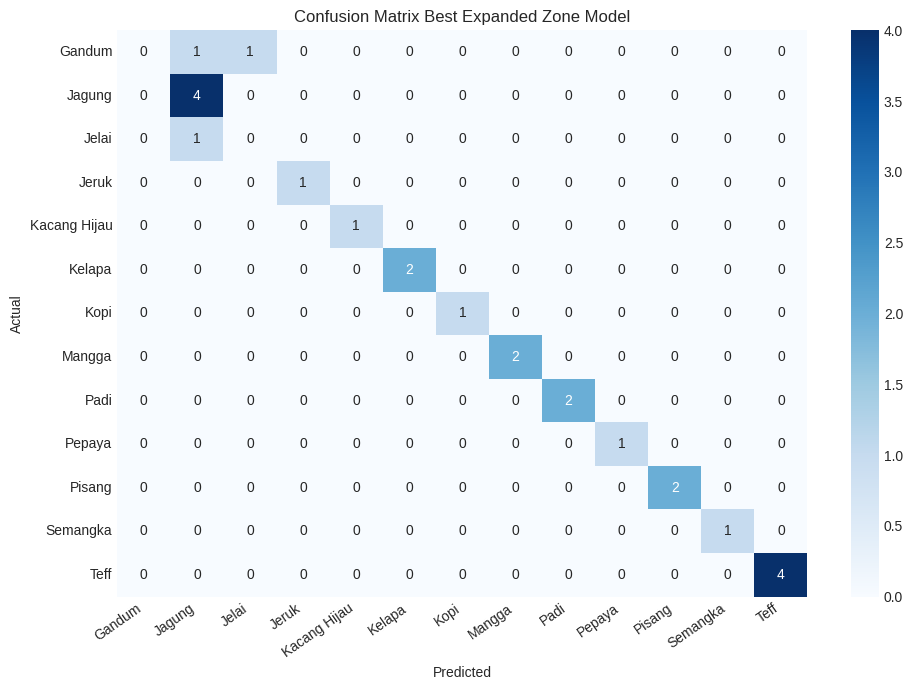

In [15]:
labels = metrics_payload["selected_zone_confusion_matrix_labels"]
matrix = np.asarray(metrics_payload["selected_zone_confusion_matrix"])

plt.figure(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Best Expanded Zone Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()


In [16]:
display(per_class_df)

low_support_df = per_class_df.loc[per_class_df["support"] <= 4].copy()
print("Kelas dengan support rendah (<=4 zona pada holdout):")
display(low_support_df)


,label,precision,recall,f1_score,support
0,Jeruk,1.0000,1.0,1.0,1
1,Kacang Hijau,1.0000,1.0,1.0,1
2,Kopi,1.0000,1.0,1.0,1
3,Pepaya,1.0000,1.0,1.0,1
4,Semangka,1.0000,1.0,1.0,1
5,Jelai,0.0000,0.0,0.0,1
6,Kelapa,1.0000,1.0,1.0,2
7,Mangga,1.0000,1.0,1.0,2
8,Padi,1.0000,1.0,1.0,2
9,Pisang,1.0000,1.0,1.0,2


Kelas dengan support rendah (<=4 zona pada holdout):


,label,precision,recall,f1_score,support
0,Jeruk,1.0000,1.0,1.0,1
1,Kacang Hijau,1.0000,1.0,1.0,1
2,Kopi,1.0000,1.0,1.0,1
3,Pepaya,1.0000,1.0,1.0,1
4,Semangka,1.0000,1.0,1.0,1
5,Jelai,0.0000,0.0,0.0,1
6,Kelapa,1.0000,1.0,1.0,2
7,Mangga,1.0000,1.0,1.0,2
8,Padi,1.0000,1.0,1.0,2
9,Pisang,1.0000,1.0,1.0,2


## 9. Feature Importance dan Interpretabilitas

Ini membantu menghubungkan model ke insight yang bisa ditindaklanjuti.


,feature,importance_mean,importance_std
0,sample_count,0.0,0.0
1,ph_count,0.0,0.0
2,ph_min,0.0,0.0
3,nitrogen_missing_ratio,0.0,0.0
4,nitrogen_range,0.0,0.0
5,nitrogen_count,0.0,0.0
6,nitrogen_max,0.0,0.0
7,ph_missing_ratio,0.0,0.0
8,ph_cv,0.0,0.0
9,temperature_mean_min,0.0,0.0


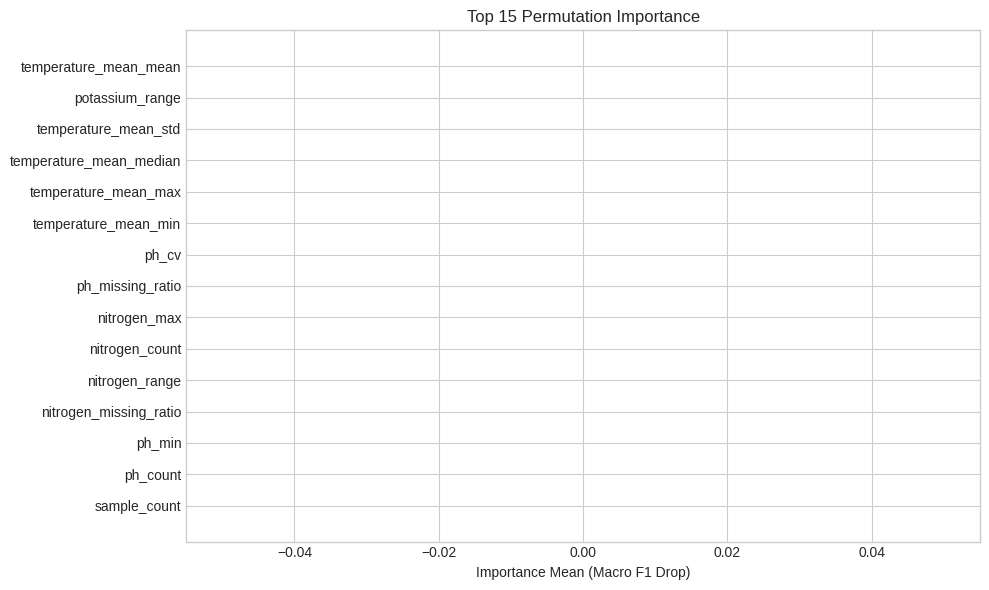

In [17]:
display(importance_df.head(20))

plt.figure(figsize=(10, 6))
top_imp = importance_df.head(15).sort_values("importance_mean", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.title("Top 15 Permutation Importance")
plt.xlabel("Importance Mean (Macro F1 Drop)")
plt.tight_layout()


## 10. Pemanfaatan AI dan Azure

Model prediksi inti tetap model tabular supervised. Di atasnya, project saat ini menambahkan **layer strategic advisor** berbasis Azure OpenAI untuk menerjemahkan output model menjadi rekomendasi tindakan yang lebih operasional.


In [18]:
settings = Settings.from_env()
azure_summary = pd.DataFrame(
    [
        {"setting": "azure_openai_enabled", "value": settings.azure_openai_enabled},
        {"setting": "azure_openai_endpoint", "value": settings.azure_openai_endpoint},
        {"setting": "azure_openai_deployment", "value": settings.azure_openai_deployment},
        {"setting": "azure_openai_use_entra_id", "value": settings.azure_openai_use_entra_id},
        {"setting": "active_zone_scenario", "value": settings.active_zone_scenario},
        {"setting": "zone_model_path", "value": str(settings.zone_model_path.relative_to(settings.project_root))},
    ]
)
display(azure_summary)


,setting,value
0,azure_openai_enabled,False
1,azure_openai_endpoint,None
2,azure_openai_deployment,None
3,azure_openai_use_entra_id,False
4,active_zone_scenario,zone_mean_plus_variability
5,zone_model_path,artifacts/models/best_zone_model_expanded.joblib


In [19]:
azure_architecture = pd.DataFrame(
    [
        {
            "layer": "Tabular zone classifier",
            "implementation": metrics_payload["selected_zone_model_name"],
            "artifact": "artifacts/models/best_zone_model_expanded.joblib",
        },
        {
            "layer": "Inference API",
            "implementation": "FastAPI /predict/zone",
            "artifact": "app/main.py",
        },
        {
            "layer": "Strategic advisor",
            "implementation": "FastAPI /insights/zone-strategy + Azure OpenAI fallback",
            "artifact": "app/services/strategic_advisor.py",
        },
    ]
)
display(azure_architecture)


,layer,implementation,artifact
0,Tabular zone classifier,extra_trees,artifacts/models/best_zone_model_expanded.joblib
1,Inference API,FastAPI /predict/zone,app/main.py
2,Strategic advisor,FastAPI /insights/zone-strategy + Azure OpenAI...,app/services/strategic_advisor.py


## 11. Insight dan Solusi Strategis

Section ini menautkan output model ke dampak praktis. Notebook memuat scorecard internal dan artefak insight yang bisa langsung dipresentasikan.


In [20]:
display(Markdown(SCORECARD_PATH.read_text(encoding="utf-8")))


# Submission Scorecard

Dokumen ini adalah **penilaian internal heuristik** terhadap submission saat ini setelah audit model dan perubahan pendukung.

## Ringkasan Skor

- Metodologi dan Eksplorasi Data: **21/25**
- Performa Model dan Kualitas Kode: **22/25**
- Pemanfaatan AI dan Layanan Microsoft Azure: **22/30**
- Insight dan Solusi Strategis: **17/20**
- Total indikatif: **82/100**

## 1. Metodologi dan Eksplorasi Data

Nilai: **21/25**

Alasan utama:
- Sudah memakai framing zona, bukan satu titik, dan split evaluasi memakai `base_context_id`.
- Merge dataset tambahan terdokumentasi dan tidak dilakukan secara sembarangan.
- Fitur aktif model cukup bersih dan overlap antarsumber dijaga.

Gap yang masih menahan skor:
- Anchor data masih bukan zona lapangan Indonesia yang eksplisit.
- Masih ada `13` kelas dengan support sangat kecil pada holdout evaluation.
- EDA sudah lebih rapi, tetapi insight spasial dan validasi unit antar-sumber masih belum setara studi lapangan penuh.

## 2. Performa Model dan Kualitas Kode

Nilai: **22/25**

Metrik utama model terpilih:
- Accuracy: **0.8750**
- Macro precision: **0.8205**
- Macro recall: **0.8462**
- Macro F1: **0.8308**
- Weighted F1: **0.8417**
- Group-aware CV macro F1: **0.8057**

Alasan utama:
- Seleksi model memakai macro F1 dan group-aware CV, bukan accuracy saja.
- Artifact evaluasi sudah lengkap: confusion matrix, classification report, per-class metrics, feature importance.
- Kode pipeline modular dan inference tidak mengubah kontrak feature order model.

Gap yang masih menahan skor:
- CV efektif masih hanya 2 fold karena ukuran data dan constraint group.
- Performa holdout bagus, tetapi robustness antar-domain tetap dibatasi ukuran dataset.

## 3. Pemanfaatan AI dan Layanan Microsoft Azure

Nilai: **22/30**

Kekuatan:
- Service inference sekarang mendukung **Azure OpenAI** sebagai lapisan strategic advisor di atas model tabular.
- Integrasi dirancang dengan **API key** maupun **Microsoft Entra ID**.
- Structured output dipakai agar respons AI bisa tetap terparse secara deterministik.

Gap yang masih menahan skor:
- Integrasi Azure masih bersifat **optional runtime**, belum dibuktikan sebagai deployment Azure produksi.
- Belum ada konfigurasi Azure ML online endpoint, monitoring, atau observability Azure native pada repo ini.
- Belum ada bukti operasional biaya, latency, dan fallback policy di environment Azure nyata.

## 4. Insight dan Solusi Strategis

Nilai: **17/20**

Kekuatan:
- Model tidak hanya memberi label, tetapi bisa diterjemahkan menjadi rekomendasi aksi strategis berbasis zona.
- Insight kini bisa dihasilkan melalui endpoint strategis dengan fokus monitoring, risiko, dan rencana tindakan.
- Fitur paling berpengaruh saat ini: ['sample_count', 'ph_count', 'ph_min', 'nitrogen_missing_ratio', 'nitrogen_range']

Gap yang masih menahan skor:
- Insight masih sangat tergantung pada kualitas pseudo-zone dan belum tervalidasi dengan agronom lapangan Indonesia.
- Belum ada feedback loop pengguna atau dampak ekonomi/agronomi pasca rekomendasi.

## Prioritas Peningkatan Berikutnya

1. Deploy inference API ke **Azure Machine Learning Online Endpoint** atau App Service/Container Apps agar pemanfaatan Azure tidak hanya optional.
2. Tambah data zona Indonesia yang benar-benar punya batas field, geolokasi, dan histori tindakan lapangan.
3. Tambah evaluasi robustness antarsumber dan kalibrasi probabilitas model.
4. Hubungkan strategic advisor ke log observability agar bisa dievaluasi kualitas rekomendasinya dari waktu ke waktu.

## Sumber Internal yang Dipakai

- `artifacts/best_model_metrics_expanded.json`
- `artifacts/model_selection_analysis_expanded.md`
- `data/processed/zone_dataset_expanded_id_metadata.json`
- `artifacts/per_class_metrics_expanded.csv`
- `artifacts/feature_importance_best_model_expanded.csv`


In [21]:
final_summary = pd.DataFrame(
    [
        {"item": "Best Model", "value": metrics_payload["selected_zone_model_name"]},
        {"item": "Best Scenario", "value": metrics_payload["selected_zone_scenario"]},
        {"item": "Best Accuracy", "value": metrics_payload["selected_zone_test_metrics"]["accuracy"]},
        {"item": "Best Macro F1", "value": metrics_payload["selected_zone_test_metrics"]["f1_macro"]},
        {"item": "Best Macro Precision", "value": metrics_payload["selected_zone_test_metrics"]["precision_macro"]},
        {"item": "Best Macro Recall", "value": metrics_payload["selected_zone_test_metrics"]["recall_macro"]},
        {"item": "Selected CV Metric", "value": metrics_payload["selected_zone_cv_metric_value"]},
    ]
)
display(final_summary)


,item,value
0,Best Model,extra_trees
1,Best Scenario,zone_mean_plus_variability
2,Best Accuracy,0.875
3,Best Macro F1,0.830769
4,Best Macro Precision,0.820513
5,Best Macro Recall,0.846154
6,Selected CV Metric,0.805739


## 12. Kesimpulan

Notebook ini menunjukkan bahwa model aktif saat ini:
- menggunakan **dataset zona expanded**
- memilih model berdasarkan **macro F1** dan **group-aware CV**
- mendukung **AI strategic layer** berbasis Azure OpenAI
- memiliki artefak evaluasi yang lebih siap presentasi dibanding pipeline sebelumnya

Keterbatasan yang tetap harus dijelaskan secara jujur:
- sebagian zona masih pseudo-zone, belum boundary lapangan Indonesia yang nyata
- beberapa kelas masih low-support
- integrasi Azure sudah ada, tetapi belum deployment penuh ke layanan Azure produksi
